# PageRank Algorithm for Building Spaces

PageRank is a link analysis algorithm originally developed by Google to rank web pages. It measures the importance of nodes in a graph based on the structure of connections. In the context of building spaces:

- **High PageRank** = Important/central spaces that are well-connected or connected to important spaces
- **Low PageRank** = Peripheral spaces with few connections to important areas

This notebook demonstrates:
1. Creating a building layout (CellComplex) using topologic_fast
2. Generating a dual graph (rooms as vertices, shared walls as edges)
3. Computing PageRank for each room using `Graph.PageRank`
4. Visualizing the results

**Note**: This notebook uses topologic_fast's native `Graph.PageRank` implementation.

In [1]:
import topologic_fast as tf
import plotly.graph_objects as go
import numpy as np

## Create the Building Geometry

We'll create a 10-room building with various connections via doors.

In [2]:
# Create room geometry (similar to topologicpy example)
# Using Cell.Box instead of Cell.Prism

# Room dimensions: Box(origin_x, origin_y, origin_z, width, length, height)
r1 = tf.Cell.Box(0, 4.5, 0, 3, 7.5, 3)      # Room 1
r2 = tf.Cell.Box(0, 0, 0, 3, 4.5, 3)        # Room 2
r3 = tf.Cell.Box(3, 7.5, 0, 3, 4.5, 3)      # Room 3
r4 = tf.Cell.Box(3, 0, 0, 3, 7.5, 3)        # Room 4
r5 = tf.Cell.Box(6, 6, 0, 3, 6, 3)          # Room 5
r6 = tf.Cell.Box(6, 0, 0, 3, 6, 3)          # Room 6
r7 = tf.Cell.Box(9, 7.5, 0, 3, 4.5, 3)      # Room 7
r8 = tf.Cell.Box(9, 3, 0, 3, 4.5, 3)        # Room 8
r9 = tf.Cell.Box(12, 3, 0, 3, 9, 3)         # Room 9
r10 = tf.Cell.Box(9, 0, 0, 6, 3, 3)         # Room 10

rooms = [r1, r2, r3, r4, r5, r6, r7, r8, r9, r10]
room_names = [
    "Room 1", "Room 2", "Room 3", "Room 4", "Room 5",
    "Room 6", "Room 7", "Room 8", "Room 9", "Room 10"
]

print(f"Created {len(rooms)} rooms")
for i, room in enumerate(rooms):
    vol = room.Volume()
    print(f"  {room_names[i]}: Volume = {vol:.1f} m^3")

Created 10 rooms
  Room 1: Volume = 67.5 m^3
  Room 2: Volume = 40.5 m^3
  Room 3: Volume = 40.5 m^3
  Room 4: Volume = 67.5 m^3
  Room 5: Volume = 54.0 m^3
  Room 6: Volume = 54.0 m^3
  Room 7: Volume = 40.5 m^3
  Room 8: Volume = 40.5 m^3
  Room 9: Volume = 81.0 m^3
  Room 10: Volume = 54.0 m^3


## Create CellComplex

Combine all rooms into a CellComplex, which represents the topological structure of the building.

In [3]:
# Create the CellComplex from the rooms
building = tf.CellComplex.ByCells(rooms)

print(f"CellComplex created:")
print(f"  Cells (rooms): {building.NumCells()}")
print(f"  Total volume: {building.Volume():.1f} m^3")
print(f"  Total surface area: {building.Area():.1f} m^2")

CellComplex created:
  Cells (rooms): 10
  Total volume: 540.0 m^3
  Total surface area: 900.0 m^2


## Create Dual Graph

The dual graph represents room connectivity:
- Each room becomes a vertex (at its centroid)
- Rooms that share a face (wall) are connected by an edge

In [4]:
# Create the dual graph from the CellComplex
# This creates vertices at cell centroids and edges between cells that share faces
graph = tf.Graph.ByTopology(building)

print(f"Dual Graph created:")
print(f"  Vertices (rooms): {graph.Order()}")
print(f"  Edges (connections): {graph.Size()}")
print(f"  Density: {graph.Density():.3f}")
print(f"  Diameter: {graph.Diameter()}")

Dual Graph created:
  Vertices (rooms): 10
  Edges (connections): 18
  Density: 0.400
  Diameter: 4


## Visualize the Building and Graph

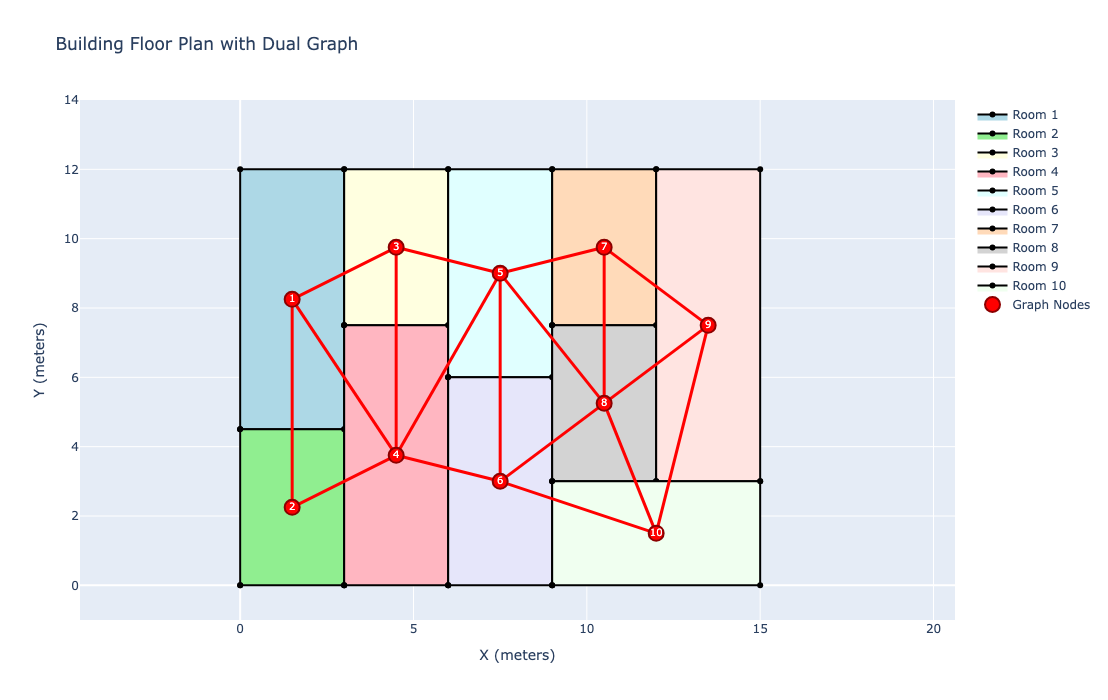

In [5]:
def visualize_building_and_graph(cellcomplex, graph, room_names):
    """
    Create a 2D visualization of the building floor plan with the dual graph overlay.
    """
    fig = go.Figure()
    
    cells = cellcomplex.Cells()
    colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightpink', 'lightcyan',
              'lavender', 'peachpuff', 'lightgray', 'mistyrose', 'honeydew']
    
    # Draw rooms (bottom faces)
    for i, cell in enumerate(cells):
        faces = cell.Faces()
        for face in faces:
            vertices = face.Vertices()
            coords = [v.Coordinates() for v in vertices]
            z_coords = [c[2] for c in coords]
            # Find bottom face (z = 0)
            if all(abs(z) < 0.01 for z in z_coords):
                x = [c[0] for c in coords] + [coords[0][0]]
                y = [c[1] for c in coords] + [coords[0][1]]
                
                fig.add_trace(go.Scatter(
                    x=x, y=y,
                    fill='toself',
                    fillcolor=colors[i % len(colors)],
                    line=dict(color='black', width=2),
                    name=room_names[i],
                    hoverinfo='name',
                    showlegend=True
                ))
                break
    
    # Draw graph edges
    graph_edges = graph.Edges()
    for edge in graph_edges:
        verts = edge.Vertices()
        if len(verts) == 2:
            p1 = verts[0].Coordinates()
            p2 = verts[1].Coordinates()
            fig.add_trace(go.Scatter(
                x=[p1[0], p2[0]],
                y=[p1[1], p2[1]],
                mode='lines',
                line=dict(color='red', width=3),
                showlegend=False,
                hoverinfo='skip'
            ))
    
    # Draw graph vertices
    graph_vertices = graph.Vertices()
    x = [v.Coordinates()[0] for v in graph_vertices]
    y = [v.Coordinates()[1] for v in graph_vertices]
    
    fig.add_trace(go.Scatter(
        x=x, y=y,
        mode='markers+text',
        marker=dict(size=15, color='red', line=dict(color='darkred', width=2)),
        text=[str(i+1) for i in range(len(graph_vertices))],
        textposition='middle center',
        textfont=dict(size=10, color='white'),
        hovertext=room_names,
        hoverinfo='text',
        name='Graph Nodes',
        showlegend=True
    ))
    
    fig.update_layout(
        title='Building Floor Plan with Dual Graph',
        xaxis=dict(title='X (meters)', scaleanchor='y', scaleratio=1, range=[-1, 17]),
        yaxis=dict(title='Y (meters)', range=[-1, 14]),
        width=900,
        height=700,
        showlegend=True,
        legend=dict(x=1.02, y=1)
    )
    
    return fig

fig = visualize_building_and_graph(building, graph, room_names)
fig.show()

## Compute PageRank

PageRank assigns each node a score based on:
- The number of incoming links
- The importance (PageRank) of linking nodes

For undirected graphs (like our building), edges are bidirectional.

topologic_fast provides `Graph.PageRank()` using a power iteration algorithm.

In [6]:
# Compute PageRank using topologic_fast's native implementation
# Parameters: damping (default 0.85), max_iterations (default 100), tolerance (default 1e-6)

pagerank_scores = graph.PageRank(damping=0.85, max_iterations=100, tolerance=1e-6)

print("PageRank Scores (computed with topologic_fast):")
print([round(x, 4) for x in pagerank_scores])

# Also get the adjacency matrix for analysis
adj_matrix = graph.AdjacencyMatrix()
print("\nAdjacency Matrix:")
for row in adj_matrix:
    print(row)

PageRank Scores (computed with topologic_fast):
[0.0898, 0.0637, 0.0861, 0.137, 0.1316, 0.1069, 0.0839, 0.1318, 0.085, 0.0842]

Adjacency Matrix:
[0, 1, 1, 1, 0, 0, 0, 0, 0, 0]
[1, 0, 0, 1, 0, 0, 0, 0, 0, 0]
[1, 0, 0, 1, 1, 0, 0, 0, 0, 0]
[1, 1, 1, 0, 1, 1, 0, 0, 0, 0]
[0, 0, 1, 1, 0, 1, 1, 1, 0, 0]
[0, 0, 0, 1, 1, 0, 0, 1, 0, 1]
[0, 0, 0, 0, 1, 0, 0, 1, 1, 0]
[0, 0, 0, 0, 1, 1, 1, 0, 1, 1]
[0, 0, 0, 0, 0, 0, 1, 1, 0, 1]
[0, 0, 0, 0, 0, 1, 0, 1, 1, 0]


## Room Ranking by PageRank

In [7]:
# Get vertex coordinates to match rooms
graph_vertices = graph.Vertices()
vertex_coords = [v.Coordinates() for v in graph_vertices]

print("Graph vertex coordinates (room centroids):")
for i, coord in enumerate(vertex_coords):
    print(f"  Vertex {i}: ({coord[0]:.2f}, {coord[1]:.2f}, {coord[2]:.2f})")

# Create ranking
room_pr_pairs = list(zip(range(len(pagerank_scores)), pagerank_scores))
room_pr_pairs.sort(key=lambda x: -x[1])

print("\nRooms Ranked by PageRank (Importance):")
print("=" * 50)
for rank, (room_idx, pr) in enumerate(room_pr_pairs, 1):
    coord = vertex_coords[room_idx]
    print(f"{rank}. Room at ({coord[0]:.1f}, {coord[1]:.1f}): PR = {pr:.4f}")

Graph vertex coordinates (room centroids):
  Vertex 0: (1.50, 8.25, 1.50)
  Vertex 1: (1.50, 2.25, 1.50)
  Vertex 2: (4.50, 9.75, 1.50)
  Vertex 3: (4.50, 3.75, 1.50)
  Vertex 4: (7.50, 9.00, 1.50)
  Vertex 5: (7.50, 3.00, 1.50)
  Vertex 6: (10.50, 9.75, 1.50)
  Vertex 7: (10.50, 5.25, 1.50)
  Vertex 8: (13.50, 7.50, 1.50)
  Vertex 9: (12.00, 1.50, 1.50)

Rooms Ranked by PageRank (Importance):
1. Room at (4.5, 3.8): PR = 0.1370
2. Room at (10.5, 5.2): PR = 0.1318
3. Room at (7.5, 9.0): PR = 0.1316
4. Room at (7.5, 3.0): PR = 0.1069
5. Room at (1.5, 8.2): PR = 0.0898
6. Room at (4.5, 9.8): PR = 0.0861
7. Room at (13.5, 7.5): PR = 0.0850
8. Room at (12.0, 1.5): PR = 0.0842
9. Room at (10.5, 9.8): PR = 0.0839
10. Room at (1.5, 2.2): PR = 0.0637


## Visualize PageRank on Floor Plan

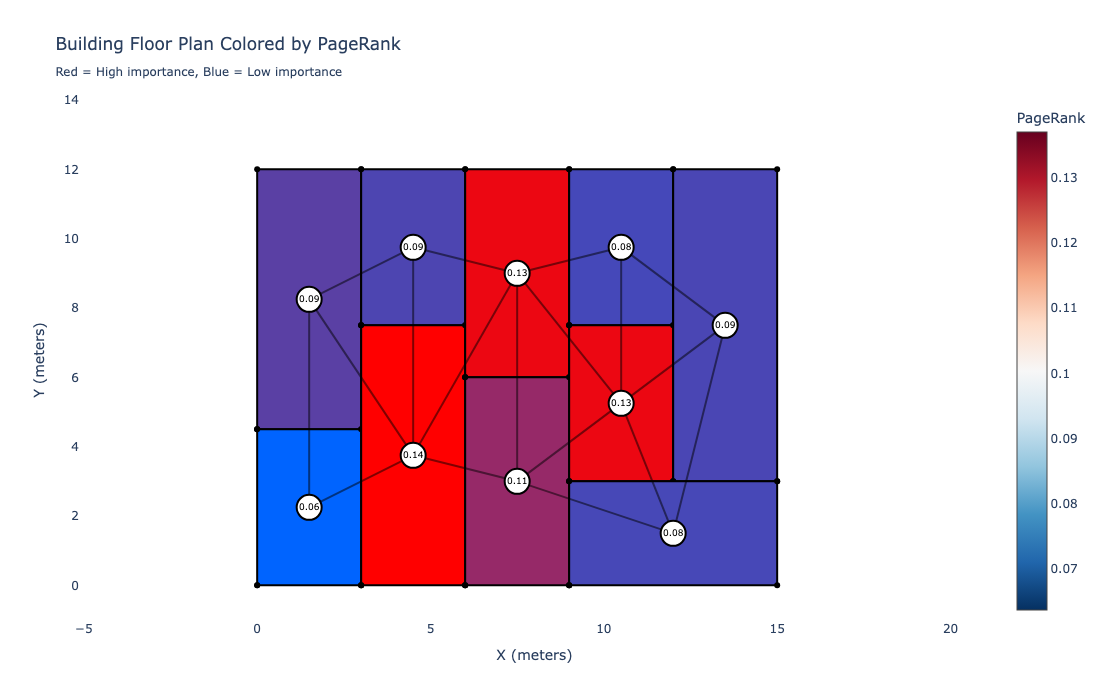

In [8]:
def visualize_pagerank(cellcomplex, graph, pagerank_scores):
    """
    Visualize the building with rooms colored by PageRank.
    """
    fig = go.Figure()
    
    cells = cellcomplex.Cells()
    graph_vertices = graph.Vertices()
    
    # Normalize PageRank for color mapping
    pr_min = min(pagerank_scores)
    pr_max = max(pagerank_scores)
    pr_range = pr_max - pr_min if pr_max > pr_min else 1
    
    # Match cells to graph vertices by centroid proximity
    cell_pr = []
    for cell in cells:
        centroid = cell.CenterOfMass()
        min_dist = float('inf')
        best_pr = 0
        for j, gv in enumerate(graph_vertices):
            gv_coord = gv.Coordinates()
            dist = ((centroid[0] - gv_coord[0])**2 + 
                    (centroid[1] - gv_coord[1])**2 + 
                    (centroid[2] - gv_coord[2])**2)**0.5
            if dist < min_dist:
                min_dist = dist
                best_pr = pagerank_scores[j]
        cell_pr.append(best_pr)
    
    # Draw rooms with PageRank coloring
    for i, cell in enumerate(cells):
        faces = cell.Faces()
        pr = cell_pr[i]
        # Normalize for color
        pr_norm = (pr - pr_min) / pr_range
        
        for face in faces:
            vertices = face.Vertices()
            coords = [v.Coordinates() for v in vertices]
            z_coords = [c[2] for c in coords]
            
            # Find bottom face
            if all(abs(z) < 0.01 for z in z_coords):
                x = [c[0] for c in coords] + [coords[0][0]]
                y = [c[1] for c in coords] + [coords[0][1]]
                
                # Color based on PageRank (red = high, blue = low)
                r = int(255 * pr_norm)
                g = int(100 * (1 - pr_norm))
                b = int(255 * (1 - pr_norm))
                color = f'rgb({r},{g},{b})'
                
                fig.add_trace(go.Scatter(
                    x=x, y=y,
                    fill='toself',
                    fillcolor=color,
                    line=dict(color='black', width=2),
                    name=f'PR: {pr:.3f}',
                    hovertext=f'PageRank: {pr:.4f}',
                    hoverinfo='text',
                    showlegend=False
                ))
                break
    
    # Add colorbar
    fig.add_trace(go.Scatter(
        x=[None], y=[None],
        mode='markers',
        marker=dict(
            colorscale='RdBu_r',
            cmin=pr_min,
            cmax=pr_max,
            colorbar=dict(title='PageRank', x=1.02),
            showscale=True
        ),
        showlegend=False
    ))
    
    # Draw graph overlay
    graph_edges = graph.Edges()
    for edge in graph_edges:
        verts = edge.Vertices()
        if len(verts) == 2:
            p1 = verts[0].Coordinates()
            p2 = verts[1].Coordinates()
            fig.add_trace(go.Scatter(
                x=[p1[0], p2[0]],
                y=[p1[1], p2[1]],
                mode='lines',
                line=dict(color='rgba(0,0,0,0.5)', width=2),
                showlegend=False,
                hoverinfo='skip'
            ))
    
    # Draw vertices with labels
    gv_coords = [v.Coordinates() for v in graph_vertices]
    x = [c[0] for c in gv_coords]
    y = [c[1] for c in gv_coords]
    labels = [f'{pr:.2f}' for pr in pagerank_scores]
    
    fig.add_trace(go.Scatter(
        x=x, y=y,
        mode='markers+text',
        marker=dict(size=25, color='white', line=dict(color='black', width=2)),
        text=labels,
        textposition='middle center',
        textfont=dict(size=9, color='black'),
        hovertext=[f'PageRank: {pr:.4f}' for pr in pagerank_scores],
        hoverinfo='text',
        showlegend=False
    ))
    
    fig.update_layout(
        title='Building Floor Plan Colored by PageRank<br><sub>Red = High importance, Blue = Low importance</sub>',
        xaxis=dict(title='X (meters)', scaleanchor='y', scaleratio=1, range=[-1, 17]),
        yaxis=dict(title='Y (meters)', range=[-1, 14]),
        width=1000,
        height=700,
        plot_bgcolor='white'
    )
    
    return fig

fig = visualize_pagerank(building, graph, pagerank_scores)
fig.show()

## Analysis of PageRank Results

In [9]:
print("PAGERANK ANALYSIS")
print("=" * 60)

# Statistics
pr_array = np.array(pagerank_scores)
print(f"\nStatistics:")
print(f"  Mean PageRank: {pr_array.mean():.4f}")
print(f"  Std deviation: {pr_array.std():.4f}")
print(f"  Min PageRank:  {pr_array.min():.4f}")
print(f"  Max PageRank:  {pr_array.max():.4f}")

# Correlation with degree
degrees = [sum(row) for row in adj_matrix]
correlation = np.corrcoef(pagerank_scores, degrees)[0, 1]
print(f"\nCorrelation with degree: {correlation:.4f}")

# Most and least important rooms
max_idx = np.argmax(pagerank_scores)
min_idx = np.argmin(pagerank_scores)

print(f"\nMost important room:")
coord = vertex_coords[max_idx]
print(f"  Vertex {max_idx} at ({coord[0]:.1f}, {coord[1]:.1f})")
print(f"  PageRank: {pagerank_scores[max_idx]:.4f}")
print(f"  Degree: {degrees[max_idx]}")

print(f"\nLeast important room:")
coord = vertex_coords[min_idx]
print(f"  Vertex {min_idx} at ({coord[0]:.1f}, {coord[1]:.1f})")
print(f"  PageRank: {pagerank_scores[min_idx]:.4f}")
print(f"  Degree: {degrees[min_idx]}")

PAGERANK ANALYSIS

Statistics:
  Mean PageRank: 0.1000
  Std deviation: 0.0240
  Min PageRank:  0.0637
  Max PageRank:  0.1370

Correlation with degree: 0.9956

Most important room:
  Vertex 3 at (4.5, 3.8)
  PageRank: 0.1370
  Degree: 5

Least important room:
  Vertex 1 at (1.5, 2.2)
  PageRank: 0.0637
  Degree: 2


## Bar Chart of PageRank Scores

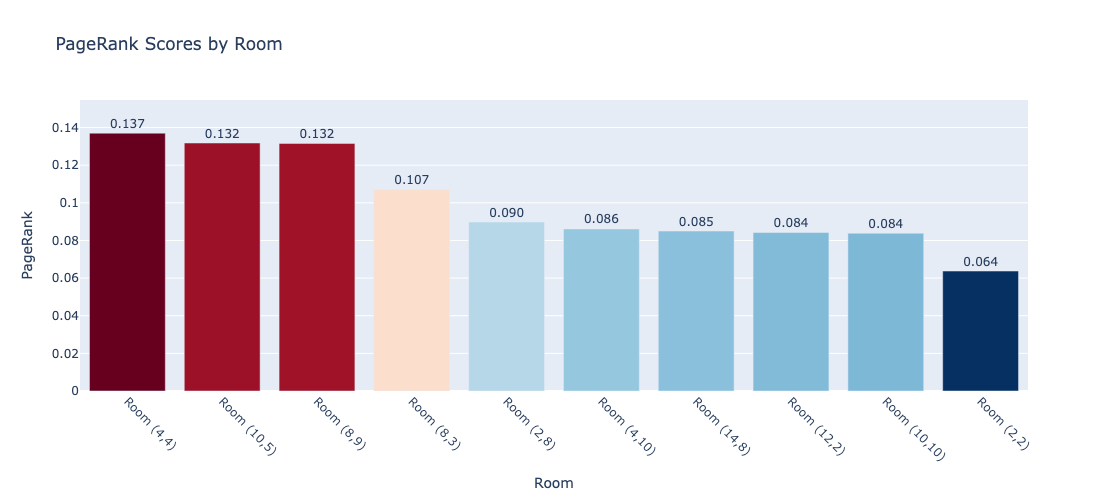

In [10]:
# Create labels based on coordinates
labels = [f"Room ({vertex_coords[i][0]:.0f},{vertex_coords[i][1]:.0f})" for i in range(len(pagerank_scores))]

# Sort by PageRank
sorted_indices = np.argsort(pagerank_scores)[::-1]
sorted_labels = [labels[i] for i in sorted_indices]
sorted_pr = [pagerank_scores[i] for i in sorted_indices]

fig = go.Figure(data=[
    go.Bar(
        x=sorted_labels,
        y=sorted_pr,
        marker_color=sorted_pr,
        marker_colorscale='RdBu_r',
        text=[f'{pr:.3f}' for pr in sorted_pr],
        textposition='outside'
    )
])

fig.update_layout(
    title='PageRank Scores by Room',
    xaxis=dict(title='Room', tickangle=45),
    yaxis=dict(title='PageRank'),
    width=900,
    height=500,
    showlegend=False
)

fig.show()

## 3D Visualization

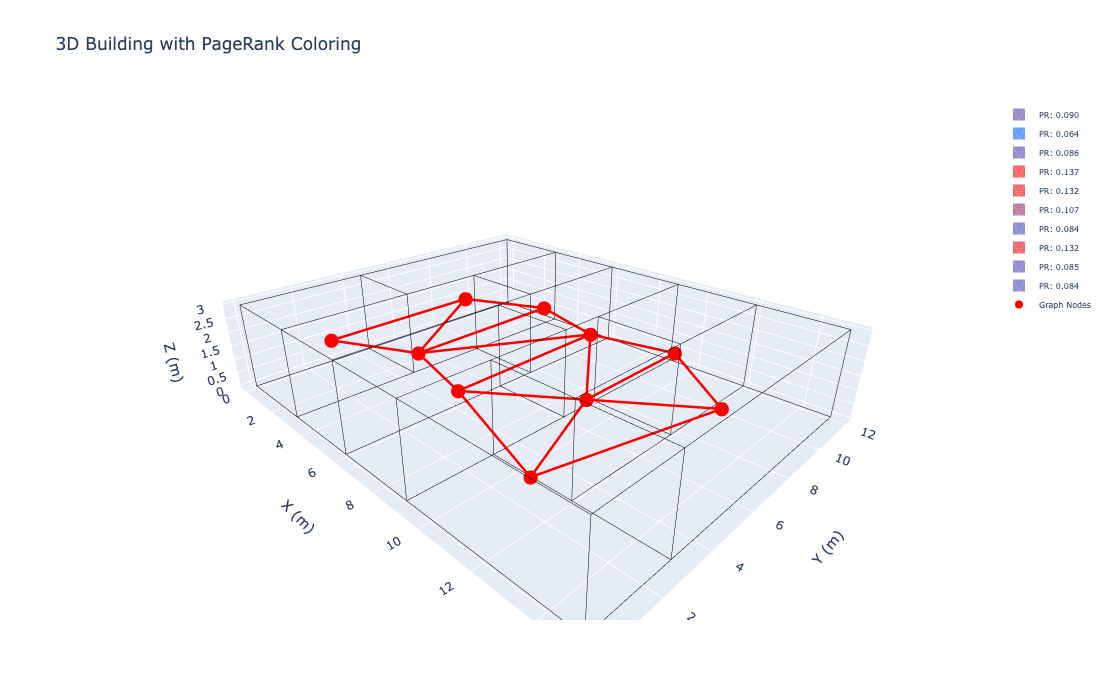

In [11]:
def visualize_3d_pagerank(cellcomplex, graph, pagerank_scores):
    """
    Create a 3D visualization with PageRank coloring.
    """
    fig = go.Figure()
    
    cells = cellcomplex.Cells()
    graph_vertices = graph.Vertices()
    
    pr_min = min(pagerank_scores)
    pr_max = max(pagerank_scores)
    pr_range = pr_max - pr_min if pr_max > pr_min else 1
    
    # Match cells to PageRank
    cell_pr = []
    for cell in cells:
        centroid = cell.CenterOfMass()
        min_dist = float('inf')
        best_pr = 0
        for j, gv in enumerate(graph_vertices):
            gv_coord = gv.Coordinates()
            dist = ((centroid[0] - gv_coord[0])**2 + 
                    (centroid[1] - gv_coord[1])**2 + 
                    (centroid[2] - gv_coord[2])**2)**0.5
            if dist < min_dist:
                min_dist = dist
                best_pr = pagerank_scores[j]
        cell_pr.append(best_pr)
    
    # Draw room faces
    for i, cell in enumerate(cells):
        faces = cell.Faces()
        pr = cell_pr[i]
        pr_norm = (pr - pr_min) / pr_range
        
        r = int(255 * pr_norm)
        g = int(100 * (1 - pr_norm))
        b = int(255 * (1 - pr_norm))
        color = f'rgb({r},{g},{b})'
        
        for j, face in enumerate(faces):
            vertices = face.Vertices()
            coords = [v.Coordinates() for v in vertices]
            
            if len(coords) >= 3:
                x = [c[0] for c in coords]
                y = [c[1] for c in coords]
                z = [c[2] for c in coords]
                
                fig.add_trace(go.Mesh3d(
                    x=x, y=y, z=z,
                    color=color,
                    opacity=0.6,
                    alphahull=0,
                    showlegend=(j == 0),
                    name=f'PR: {pr:.3f}'
                ))
                
                # Draw edges
                for k in range(len(coords)):
                    p1 = coords[k]
                    p2 = coords[(k + 1) % len(coords)]
                    fig.add_trace(go.Scatter3d(
                        x=[p1[0], p2[0]], y=[p1[1], p2[1]], z=[p1[2], p2[2]],
                        mode='lines',
                        line=dict(color='black', width=1),
                        showlegend=False,
                        hoverinfo='skip'
                    ))
    
    # Draw graph
    graph_edges = graph.Edges()
    for edge in graph_edges:
        verts = edge.Vertices()
        if len(verts) == 2:
            p1 = verts[0].Coordinates()
            p2 = verts[1].Coordinates()
            fig.add_trace(go.Scatter3d(
                x=[p1[0], p2[0]],
                y=[p1[1], p2[1]],
                z=[p1[2], p2[2]],
                mode='lines',
                line=dict(color='red', width=5),
                showlegend=False,
                hoverinfo='skip'
            ))
    
    # Draw graph vertices
    gv_coords = [v.Coordinates() for v in graph_vertices]
    x = [c[0] for c in gv_coords]
    y = [c[1] for c in gv_coords]
    z = [c[2] for c in gv_coords]
    
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(size=8, color='red'),
        hovertext=[f'PageRank: {pr:.4f}' for pr in pagerank_scores],
        hoverinfo='text',
        name='Graph Nodes'
    ))
    
    fig.update_layout(
        title='3D Building with PageRank Coloring',
        scene=dict(
            aspectmode='data',
            xaxis_title='X (m)',
            yaxis_title='Y (m)',
            zaxis_title='Z (m)',
            camera=dict(eye=dict(x=1.5, y=-1.5, z=1))
        ),
        width=1000,
        height=700,
        legend=dict(x=1.02, y=1, font=dict(size=8))
    )
    
    return fig

fig = visualize_3d_pagerank(building, graph, pagerank_scores)
fig.show()

## Summary

This notebook demonstrated:

1. **Creating building geometry** using `tf.Cell.Box` and `tf.CellComplex.ByCells`
2. **Generating a dual graph** using `tf.Graph.ByTopology`
3. **Computing PageRank** using `tf.Graph.PageRank` to measure room importance based on connectivity
4. **Visualizing results** in 2D and 3D with Plotly

### Key Insights:
- PageRank identifies central rooms that are well-connected or connected to important spaces
- Rooms with high PageRank serve as important hubs in the building
- PageRank is correlated with degree but also considers the importance of neighbors

### topologic_fast Methods Used:
- `Graph.PageRank(damping, max_iterations, tolerance)` - Power iteration algorithm
- `Graph.ByTopology` - Creates dual graphs from CellComplex
- `Graph.AdjacencyMatrix` - Retrieves graph structure

### Applications:
- Identifying important spaces in building layouts
- Wayfinding optimization
- Emergency evacuation planning
- Space syntax analysis